# Projet end-to-end de ML pour la detection des fraudes à l'assurance automobile

Le dataset contient des informations sur les véhicules ainsi que les données liées aux contrats d'assurance (type de police, durée..)

L'objectif est de determiner si une demande d'indemnisation est frauduleuse ou non.

## Import des librairies

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

## Chargement du dataset



In [3]:
path = "input/fraud_oracle.csv"
df = pd.read_csv(path)



In [4]:
# Affichage des premières lignes
#print(df.head())

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [5]:
# EXPLORATION RAPIDE DES DONNEES
# Afficher la forme du dataset et les colonnes
print("\n")
print(f"Forme du dataset: {df.shape}")
print("\n")
print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")

# Explorer les types de données et les valeurs manquantes
print("\n")
print("\nTypes de données et valeurs manquantes:")
print(df.info())

print("\n")
print("Valeurs manquantes:")
print(df.isnull().sum())



Forme du dataset: (15420, 33)


Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'Polic

In [6]:
# 2.1 EDA - ANALYSE EXPLORATOIRE DÉTAILLÉE
print("\n=== ANALYSE EXPLORATOIRE (EDA) ===")

# Statistiques descriptives
print("Statistiques descriptives:")
#print(df.describe())

#print(df.head())

print(df[category_columns].head(10))





=== ANALYSE EXPLORATOIRE (EDA) ===
Statistiques descriptives:
  Month  DayOfWeek    Make AccidentArea DayOfWeekClaimed MonthClaimed     Sex  \
0   Dec  Wednesday   Honda        Urban          Tuesday          Jan  Female   
1   Jan  Wednesday   Honda        Urban           Monday          Jan    Male   
2   Oct     Friday   Honda        Urban         Thursday          Nov    Male   
3   Jun   Saturday  Toyota        Rural           Friday          Jul    Male   
4   Jan     Monday   Honda        Urban          Tuesday          Feb  Female   
5   Oct     Friday   Honda        Urban        Wednesday          Nov    Male   
6   Feb   Saturday   Honda        Urban           Monday          Feb    Male   
7   Nov     Friday   Honda        Urban          Tuesday          Mar    Male   
8   Dec   Saturday   Honda        Urban        Wednesday          Dec    Male   
9   Apr    Tuesday    Ford        Urban        Wednesday          Apr    Male   

  MaritalStatus          Fault            Pol

Text(0.5, 1.0, 'Matrice de Corrélation')

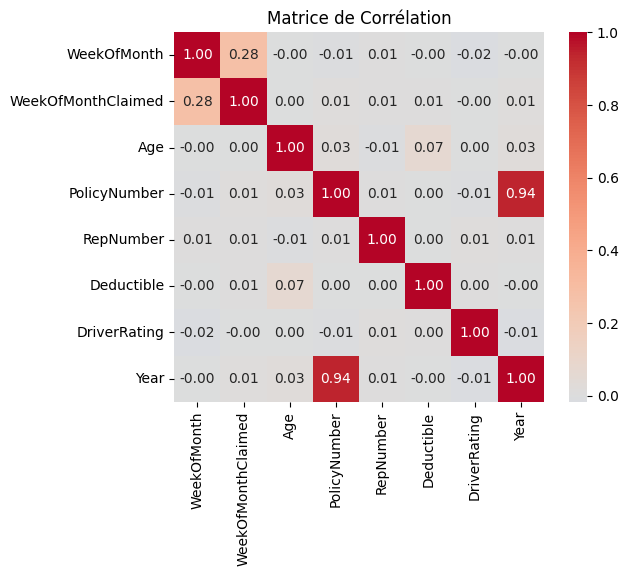

In [7]:
# Matrice de correlation
corr_matrix = df[num_colums].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matrice de Corrélation')

Text(0, 0.5, 'Âge')

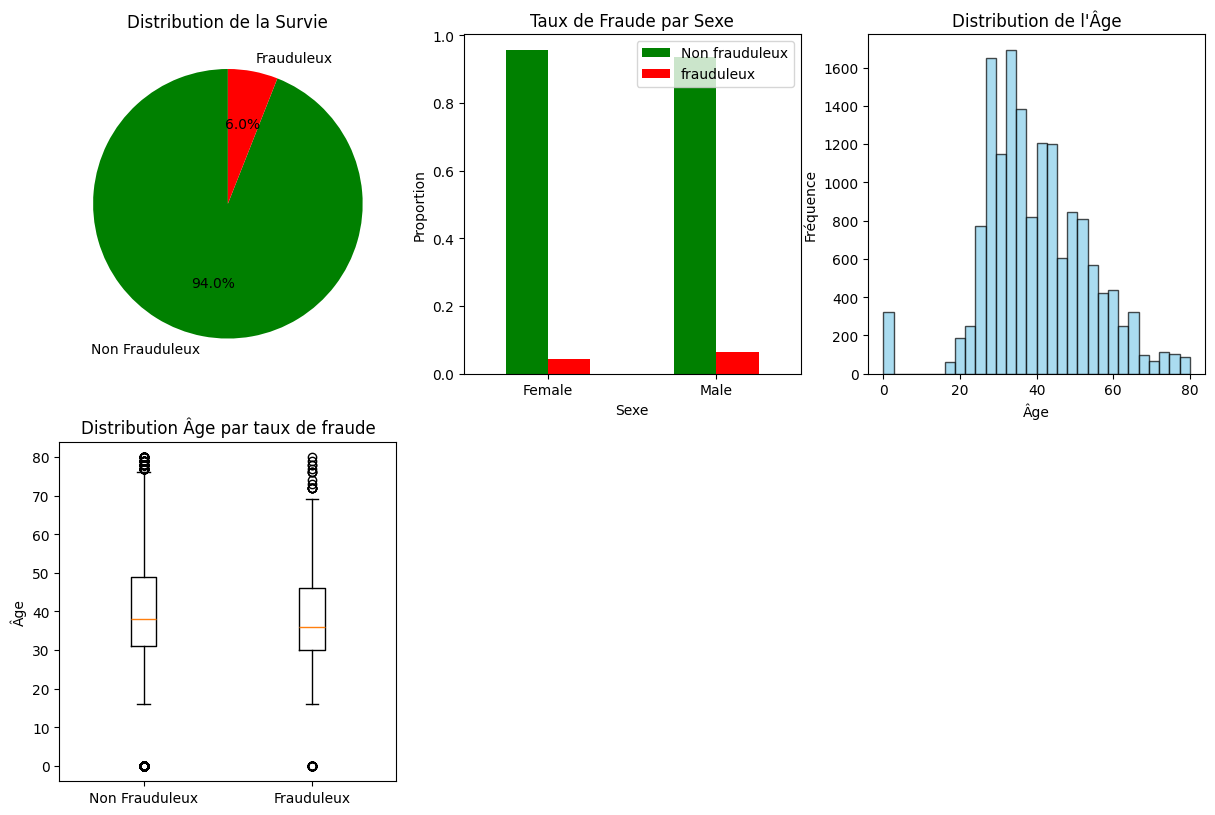

In [8]:
# EDA Visualisations
plt.figure(figsize=(20, 15))

# 1. Distribution de la variable cible
plt.subplot(3, 4, 1)
survival_counts = df['FraudFound_P'].value_counts()
plt.pie(survival_counts.values, labels=['Non Frauduleux', 'Frauduleux'], autopct='%1.1f%%', 
        colors=['green', 'red'], startangle=90)
plt.title('Distribution de la Survie')

# 2. Taux de fraude par sexe
plt.subplot(3, 4, 2)
survival_by_sex = pd.crosstab(df['Sex'], df['FraudFound_P'], normalize='index')
survival_by_sex.plot(kind='bar', color=['green', 'red'], ax=plt.gca())
plt.title('Taux de Fraude par Sexe')
plt.xlabel('Sexe')
plt.ylabel('Proportion')
plt.legend(['Non frauduleux', 'frauduleux'])
plt.xticks(rotation=0)


# 3. Distribution de l'âge
plt.subplot(3, 4, 3)
plt.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution de l\'Âge')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

# 4. Taux de fraude par âge (boxplot)
plt.subplot(3, 4, 5)
frauduleux_ages = df[df['FraudFound_P'] == 1]['Age'].dropna()
non_frauduleux_ages = df[df['FraudFound_P'] == 0]['Age'].dropna()
plt.boxplot([non_frauduleux_ages, frauduleux_ages], tick_labels=['Non Frauduleux', 'Frauduleux'])
plt.title('Distribution Âge par taux de fraude')
plt.ylabel('Âge')





## Liste des colonnes à supprimer
- PolicyNumber, RepNumber : qui sont des identifiants et donc n'apportent pas valeur pour l'entrainement
- PoliceReportFiled: rapport de police déposé (potentiellement déposé après l'accident)
- WitnessPresent: Présence de témoin
- NumberOfSuppliments: nombre de justificatifs supplémentaires

In [15]:
# verifier les features catégorielles
df[category_columns].nunique().sort_values(ascending=False)



Make                    19
MonthClaimed            13
Month                   12
PolicyType               9
AgeOfPolicyHolder        9
AgeOfVehicle             8
DayOfWeekClaimed         8
DayOfWeek                7
VehiclePrice             6
AddressChange_Claim      5
Days_Policy_Accident     5
NumberOfCars             5
PastNumberOfClaims       4
NumberOfSuppliments      4
MaritalStatus            4
Days_Policy_Claim        4
BasePolicy               3
VehicleCategory          3
Sex                      2
AccidentArea             2
Fault                    2
AgentType                2
PoliceReportFiled        2
WitnessPresent           2
dtype: int64

Étape 2 — Explorer les variables catégorielles
→ countplot par rapport à la target
→ corrélation avec Chi-2 / Cramér's V
→ décision : garder ou supprimer

Étape 3 — Explorer les variables continues
→ describe() → métriques
→ boxplot → outliers
→ décision : normaliser, discrétiser
              ou garder tel quel

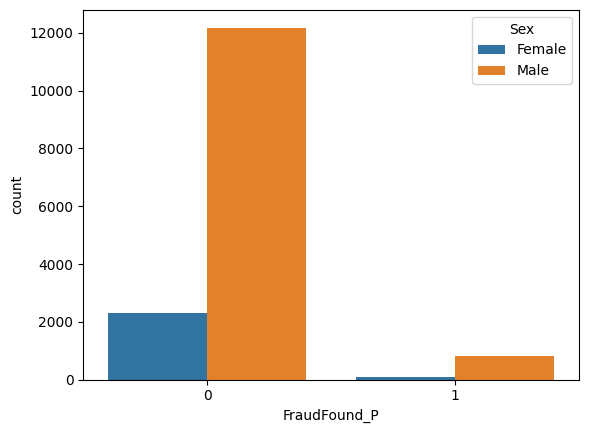

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# read a tips.csv file from seaborn library


# count plot on single categorical variable
sns.countplot(x ='FraudFound_P',hue="Sex", data = df)

plt.show()